# Personal Finance Dataset (**Complete EDA**)

## Dataset Overview

 **Description**
The Data Set was downloaded from Kaggle, from the following [link](https://www.kaggle.com/datasets/ramyapintchy/personal-finance-data?select=Personal_Finance_Dataset.csv)

This dataset encompasses personal financial transactions recorded over several years, providing a comprehensive overview of income and expenses. The data is structured in a tabular format with the following key attributes:

**`Columns`**: The dataset is consists of 5 columns named as 'Date','Transaction Description','Category','Amount','Type'.

`Date`: The date on which each transaction occurred, allowing for temporal analysis of spending and income patterns.

`Transaction Description`: A brief description of each transaction, providing context and detail about the nature of the expense or income.

`Category`: Each transaction is categorized into predefined groups such as Food & Drink, Utilities, Rent, Shopping, Health & Fitness, Travel, Entertainment, and Other. This categorization facilitates the analysis of spending patterns across various aspects of personal finance.

`Amount`: The monetary value associated with each transaction, indicating the cost of expenses or the amount of income received.

`Type`: This indicates whether the transaction is classified as an "Income" or "Expense," providing a clear distinction for financial analysis.

`Acknowledgements`
This information is Released under MIT License
1. Copyright (c) 2013 Mark Otto.
2. Copyright (c) 2017 Andrew Fong.

`Data Integrity`
The dataset is assumed to be recorded consistently, providing a reliable basis for financial analysis. However, users should validate the data and consider any potential missing values or discrepancies in transaction descriptions.

## 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2.0 Data Loading, Exploration & Cleaning
->Load the csv file with pandas

->creating the dataframe and understanding the data present in the dataset using pandas

-> Dealing with the missing data, outliers and the incorrect records

In [2]:
df = pd.read_csv("/kaggle/input/personal-finance-data/Personal_Finance_Dataset.csv")


- Looking at the dataset

In [3]:
df.head(5)

,Date,Transaction Description,Category,Amount,Type
0,2020-01-02,Score each.,Food & Drink,1485.69,Expense
1,2020-01-02,Quality throughout.,Utilities,1475.58,Expense
2,2020-01-04,Instead ahead despite measure ago.,Rent,1185.08,Expense
3,2020-01-05,Information last everything thank serve.,Investment,2291.00,Income
4,2020-01-13,Future choice whatever from.,Food & Drink,1126.88,Expense


In order to increase the limit of column and row views, we will write the below commands

In [4]:
pd.set_option('display.max_columns', None) # this is to display all the columns in the dataframe
pd.set_option('display.max_rows', None) # this is to display all the rows in the dataframe

In [5]:
# hide all warnings runtime
import warnings
warnings.filterwarnings('ignore')

Looking at the columns of the dataset

In [6]:
df.columns

Index(['Date', 'Transaction Description', 'Category', 'Amount', 'Type'], dtype='object')

Let's look at the shape of the dataset

In [7]:
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns")

The dataset has 1500 rows and 5 columns


In [8]:
# A brief overview of the columns with datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     1500 non-null   object 
 1   Transaction Description  1500 non-null   object 
 2   Category                 1500 non-null   object 
 3   Amount                   1500 non-null   float64
 4   Type                     1500 non-null   object 
dtypes: float64(1), object(4)
memory usage: 58.7+ KB


# **Observations**
---
1. There are 1500 rows and 5 columns in the dataset
2. The columns are of different same data type i.e object except amount column which is of 'float' datatype
3. The columns in the datasets are:
   - `'Date', 'Category', 'Transaction Description', 'Amount', 'Type'`
4. There are no some missing values in the dataset which is a good sign


## 3.0 Descriptive Statistics

In [9]:
# Calculate summary statistics
summary_stats = {
    'Mean': df['Amount'].mean(),
    'Median': df['Amount'].median(),
    'Mode': df['Amount'].mode()[0],  # mode() returns a Series, take the first element
    'Min': df['Amount'].min(),
    'Max': df['Amount'].max(),
    'Standard Deviation': df['Amount'].std()
}

# Convert to DataFrame for better visualization
summary_df = pd.DataFrame(summary_stats, index=[0])
print(summary_df)

          Mean    Median    Mode    Min     Max  Standard Deviation
0  1307.520913  1156.285  158.91  14.37  4996.0          982.283361


**Distribution Analysis**

Create histograms and box plots to visualize the distribution of the Amount column

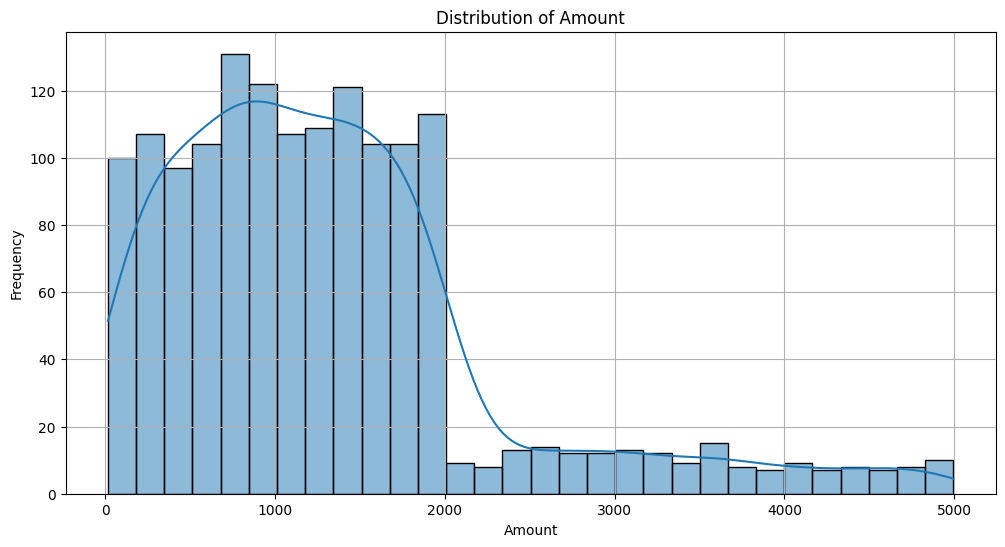

In [10]:
plt.figure(figsize=(12, 6))
sns.histplot(df['Amount'], bins=30, kde=True)  # kde=True adds a kernel density estimate
plt.title('Distribution of Amount')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.grid()
plt.show()

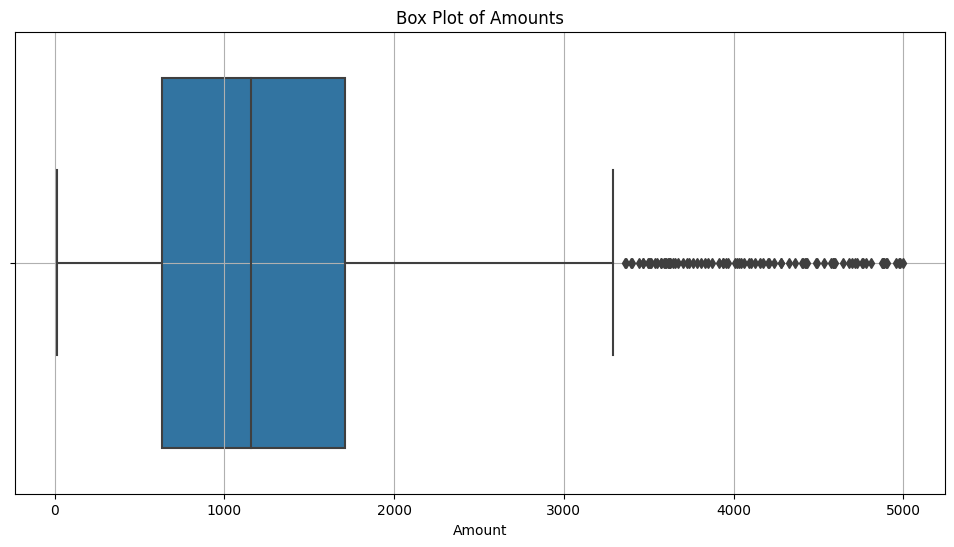

In [11]:
plt.figure(figsize=(12, 6))
sns.boxplot(x=df['Amount'])
plt.title('Box Plot of Amounts')
plt.xlabel('Amount')
plt.grid()
plt.show()

Summary of the Analysis

-> Mean, Median, Mode, Min, Max, and Standard Deviation provide insights into the central tendency and spread of the Amount data.

-> Histogram shows the frequency distribution of amounts, allowing you to visualize any skewness or the presence of multiple peaks (modes).

-> Box Plot helps identify outliers and gives a visual summary of the distribution's quartiles.

## 4.0 Categorical Analysis

Counting and visualizing the number of transactions in each category

In [12]:
# count the number of transactions per category
category_counts = df['Category'].value_counts()
print(category_counts)

Category
Rent                165
Travel              160
Utilities           157
Health & Fitness    152
Shopping            150
Food & Drink        149
Salary              146
Entertainment       143
Investment          142
Other               136
Name: count, dtype: int64


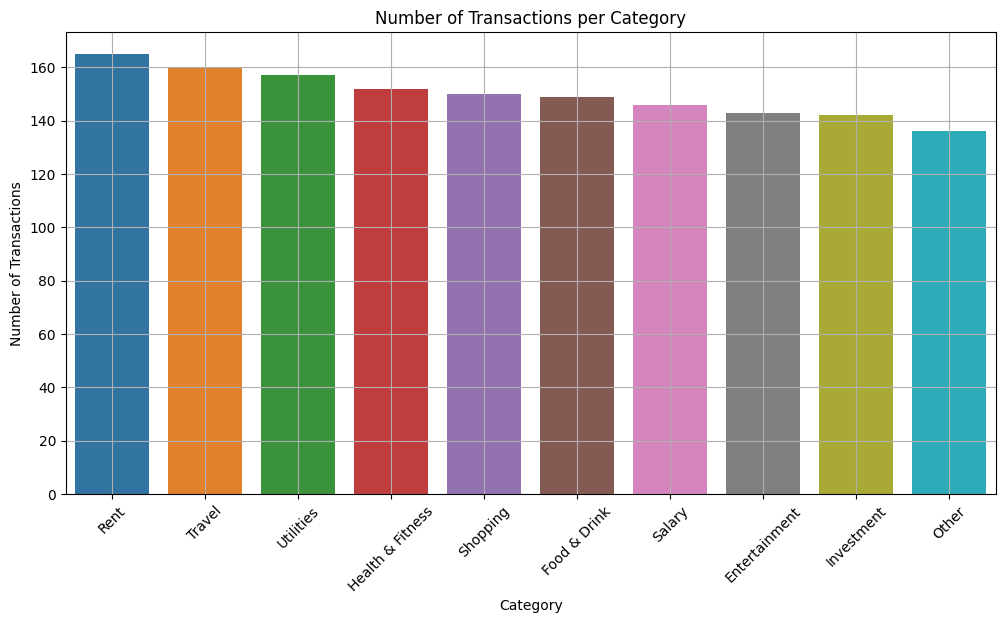

In [13]:
#plot the number of transactions per category
plt.figure(figsize=(12, 6))
sns.barplot(x=category_counts.index, y=category_counts.values)
plt.title('Number of Transactions per Category')
plt.xlabel('Category')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.grid()
plt.show()

# 5.0 Bivariate Analysis

## 5.1 Correlation Analysis

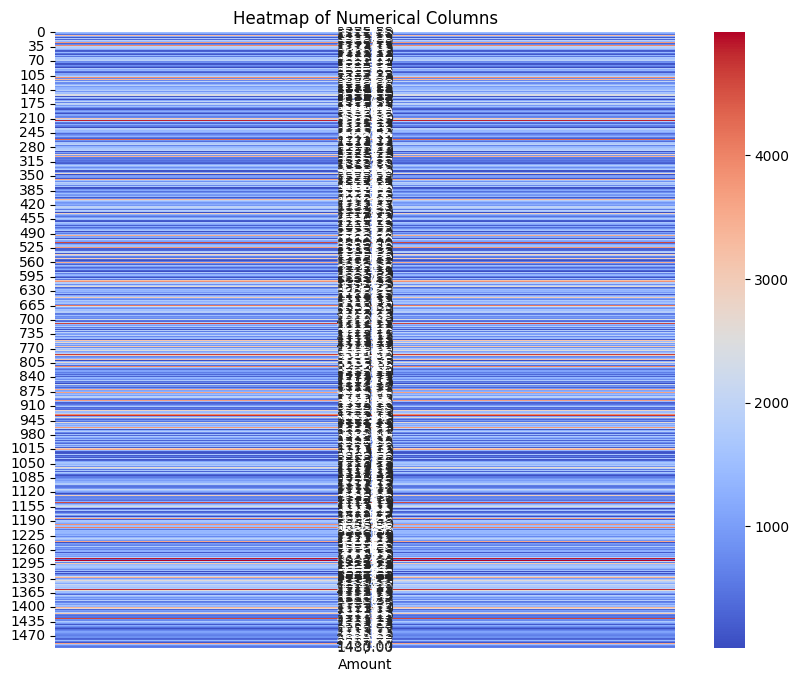

In [14]:
# create a heatmap for numerical columns
numerical_cols = df.select_dtypes(include=[np.number])  # select only numerical columns
plt.figure(figsize=(10, 8))
sns.heatmap(numerical_cols, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap of Numerical Columns')
plt.show()

        Amount
Amount     1.0


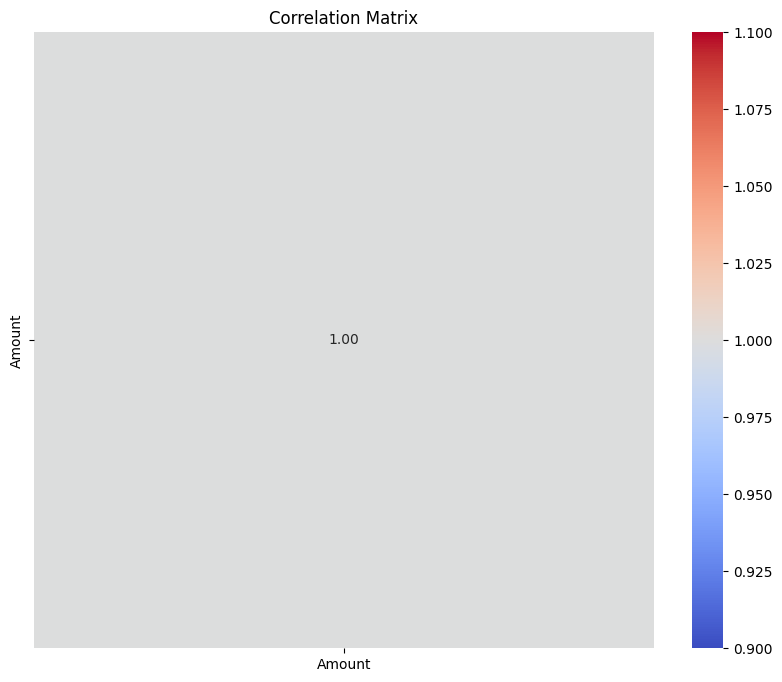

In [15]:
# create a correlation matrix for numerical columns
numerical_cols = df.select_dtypes(include=[np.number])  # select only numerical columns  
correlation_matrix = numerical_cols.corr()
print(correlation_matrix)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

## 5.2 Comparative Analysis

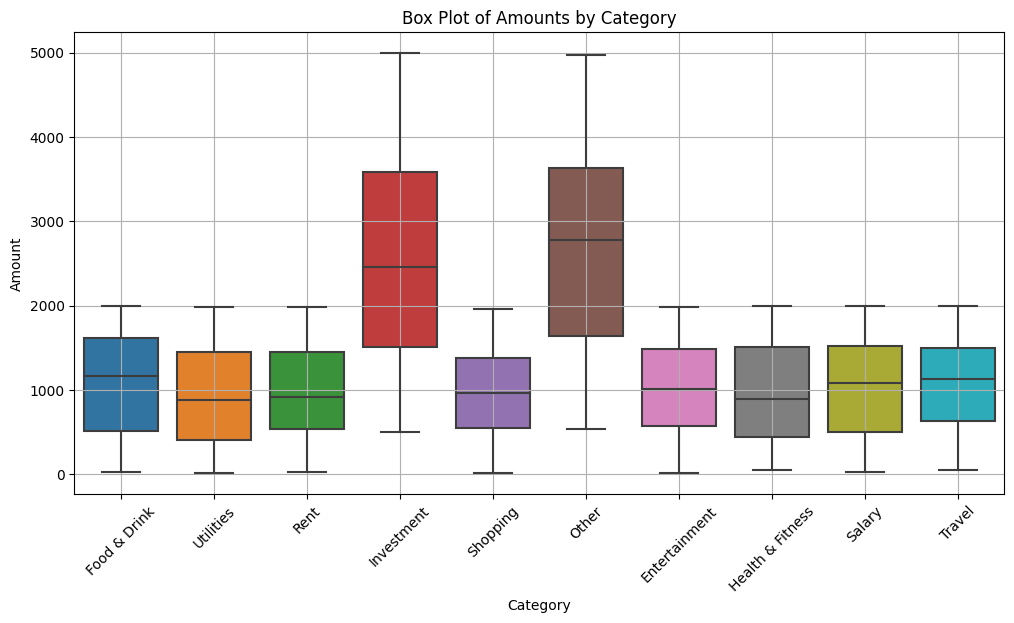

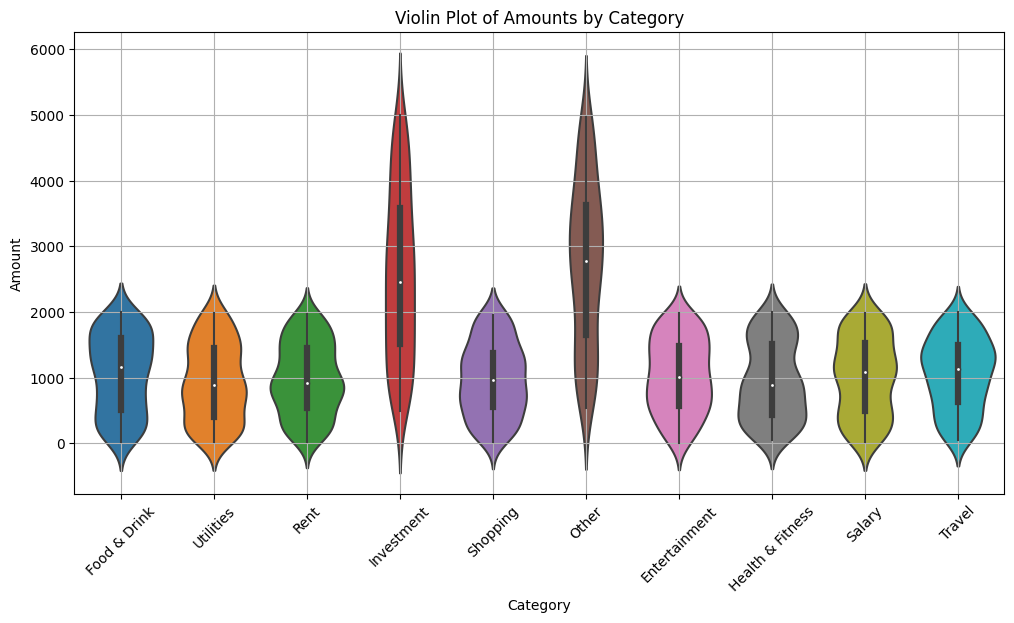

In [16]:
# create Box plots and violin plots to compare distributions across categories
plt.figure(figsize=(12, 6))
sns.boxplot(x='Category', y='Amount', data=df)
plt.title('Box Plot of Amounts by Category')
plt.xlabel('Category')
plt.ylabel('Amount')
plt.xticks(rotation=45)
plt.grid()
plt.show()
plt.figure(figsize=(12, 6))
sns.violinplot(x='Category', y='Amount', data=df)
plt.title('Violin Plot of Amounts by Category')
plt.xlabel('Category')
plt.ylabel('Amount')
plt.xticks(rotation=45)
plt.grid()
plt.show()

# 6.0 Multivariate Analysis

## 6.1 Advanced Visualizations

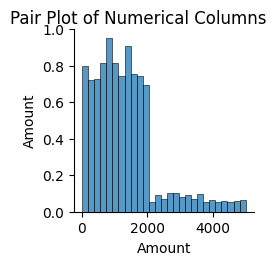

In [17]:
# create Pair plots or scatter plot matrices to explore interactions among multiple variables
sns.pairplot(df.select_dtypes(include=[np.number]))  # only include numerical columns for pairplot
plt.suptitle('Pair Plot of Numerical Columns', y=1.02)
plt.show()

## 6.2 Dimensionality Reduction

In [18]:
# perform the Techniques like PCA (Principal Component Analysis) if applicable
%pip install scikit-learn
from sklearn.decomposition import PCA

Note: you may need to restart the kernel to use updated packages.


In [19]:
# perform Techniques like PCA (Principal Component Analysis) if applicable
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Standardize the data
scaler = StandardScaler()
numerical_scaled = scaler.fit_transform(numerical_cols)

# Apply PCA
pca = PCA(n_components=1)
principal_components = pca.fit_transform(numerical_scaled)

# Add the principal component to the dataframe
df['PCA_1'] = principal_components

# Explained variance ratio
print("Explained variance ratio by the principal component:", pca.explained_variance_ratio_)
print(df[['Amount', 'PCA_1']].head())


Explained variance ratio by the principal component: [1.]
    Amount     PCA_1
0  1485.69  0.181443
1  1475.58  0.171147
2  1185.08 -0.124691
3  2291.00  1.001551
4  1126.88 -0.183960


# 7.0 Summary of Findings


1. The dataset contains **1500** rows and **6** columns.
2. The 'Amount' column has a mean of **1307.52**, median of **1156.28**, and mode of **158.91**.
3. The minimum and maximum values in the 'Amount' column are **14.37** and **4996.00**, respectively.
4. The standard deviation of the 'Amount' column is **982.28**, indicating the variability of transaction amounts.
5. The distribution of 'Amount' is visualized through histograms and box plots, revealing potential outliers.


# 8.0 About Me

**Name:** Hafiz Taqi Ul Hassan  
**Background:** Google Certified Data Analyst  
**Interests:** Data Analysis, Machine Learning, Finance, Visualization, Problem Solving, Data Driven Solutions  

<a href="https://www.linkedin.com/in/taqiulhassan" target="_blank">
    <img src="https://img.shields.io/badge/LinkedIn-Connect-blue?logo=linkedin" alt="LinkedIn" style="vertical-align:middle">
</a>
<a href="mailto:taqihassan011@gmail.com" target="_blank">
    <img src="https://img.shields.io/badge/Email-Contact-red?logo=gmail" alt="Email" style="vertical-align:middle">
</a>

*Thank you for reading my notebook! Feel free to connect or provide feedback.*